# Experience Gap Evaluation Methods
Comparative framework for modeling the Experience Gap (`Delta_E`) feature inside the CV-screening pipeline.

**Evaluation Metric:** Spearman's Rank Correlation. This measures how perfectly our mathematical models match the sorting order a real human recruiter would choose.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import spearmanr

### 1. Mathematical Adjustment Models
Here we define the three distinct ways to handle the gap between a candidate's experience and the job's requirements.

In [2]:
def linear_penalty(delta_e, slope=0.05):
    """Method A: Standard Linear Penalty. Deducts a fixed amount per year of missing experience."""
    # np.minimum ensures we only penalize deficits (negative numbers) and ignore surplus
    return np.minimum(delta_e * slope, 0)

def quadratic_penalty(delta_e, alpha=0.04, beta=0.01):
    """Method B: Human Recruiter Logic. Harsh penalty for missing years, slight reward for extra years."""
    # If deficit (< 0), apply quadratic curve. If surplus (>= 0), apply linear reward.
    return np.where(delta_e < 0, -alpha * (delta_e ** 2), beta * delta_e)

def sigmoid_bayesian_score(delta_e, match_score, k=0.35):
    """Method C: Bayesian Probability. Uses a smooth decay curve to represent confidence in the candidate."""
    # 1. Likelihood: How likely is this gap if the candidate is truly competent?
    likelihood = 1.0 / (1.0 + np.exp(-k * delta_e))

    # 2. Safety bounds: Prevent perfect 0s or 1s from breaking the math
    eps = 1e-6
    prior = np.clip(match_score, eps, 1 - eps)
    likelihood = np.clip(likelihood, eps, 1 - eps)

    # 3. Bayes Theorem: Combine initial NLP match score (Prior) with the gap (Likelihood)
    numerator = likelihood * prior
    denominator = numerator + (1 - likelihood) * (1 - prior)
    return numerator / denominator

### 2. Pipeline Application & Evaluation
Apply the formulas to the dataset and calculate which method best mimics human judgment.

In [3]:
def apply_methods(df):
    """Calculates the Delta E and applies all three adjustment methods to the dataset."""
    df = df.copy()

    # Calculate the gap (Negative = needs more experience, Positive = has extra)
    df['Delta_E'] = df['Exp_cand'] - df['Exp_req']

    # Apply penalties and ensure final scores never drop below 0 or exceed 1
    df['Score_Linear'] = np.clip(df['Match_Score'] + linear_penalty(df['Delta_E']), 0, 1)
    df['Score_Quadratic'] = np.clip(df['Match_Score'] + quadratic_penalty(df['Delta_E']), 0, 1)
    df['Score_Sigmoid'] = sigmoid_bayesian_score(df['Delta_E'], df['Match_Score'])

    return df

def evaluate_rankings(df):
    """Compares each method against a Human Target Score using Spearman Correlation."""
    if 'Human_Target_Score' not in df.columns:
        return "Missing 'Human_Target_Score' column for evaluation."

    # Calculate Spearman correlation for each method
    correlations = {
        'Linear': spearmanr(df['Human_Target_Score'], df['Score_Linear'])[0],
        'Quadratic': spearmanr(df['Human_Target_Score'], df['Score_Quadratic'])[0],
        'Sigmoid': spearmanr(df['Human_Target_Score'], df['Score_Sigmoid'])[0]
    }

    # Format the results into a clean, sorted table
    results_df = pd.DataFrame(list(correlations.items()), columns=['Method', 'Spearman_Score'])
    results_df = results_df.sort_values(by='Spearman_Score', ascending=False).reset_index(drop=True)

    return results_df

### 3. Visual Comparison
Plot the behavior of all three methods to visually confirm how aggressively they penalize candidates.

In [4]:
def plot_method_comparison(baseline_score=0.75):
    """Generates a line graph comparing the score drops across a 10-year experience swing."""
    # Generate hypothetical experience gaps from -5 to +5 years
    delta_e = np.linspace(-5, 5, 200)
    base_scores = np.full_like(delta_e, baseline_score)

    # Calculate adjusted scores for the graph
    y_linear = np.clip(base_scores + linear_penalty(delta_e), 0, 1)
    y_quad = np.clip(base_scores + quadratic_penalty(delta_e), 0, 1)
    y_sigmoid = sigmoid_bayesian_score(delta_e, base_scores)

    # Build the plot
    plt.figure(figsize=(10, 6))
    plt.plot(delta_e, y_linear, label="Linear (Baseline)", linestyle="--", color="#4A90E2")
    plt.plot(delta_e, y_quad, label="Quadratic (Deployed)", linewidth=2.5, color="#F5A623")
    plt.plot(delta_e, y_sigmoid, label="Sigmoid-Bayesian (Proposed)", linewidth=2.5, color="#50E3C2")

    # Add reference lines and styling
    plt.axvline(0, color="#9B9B9B", linestyle=":", label="Exact Match (0 Gap)")
    plt.axhline(baseline_score, color="#9B9B9B", linestyle=":", alpha=0.6)

    plt.xlabel("Experience Mismatch (Years)", fontweight='bold')
    plt.ylabel("Final Adjusted Match Score", fontweight='bold')
    plt.title(f"Experience Gap Penalty Curves (Baseline Score = {baseline_score})", fontsize=14, fontweight='bold')
    plt.legend(loc="lower right")
    plt.grid(alpha=0.3)
    plt.show()

### 4. Execute Demonstration
Run the visualization and test the logic on dummy data.

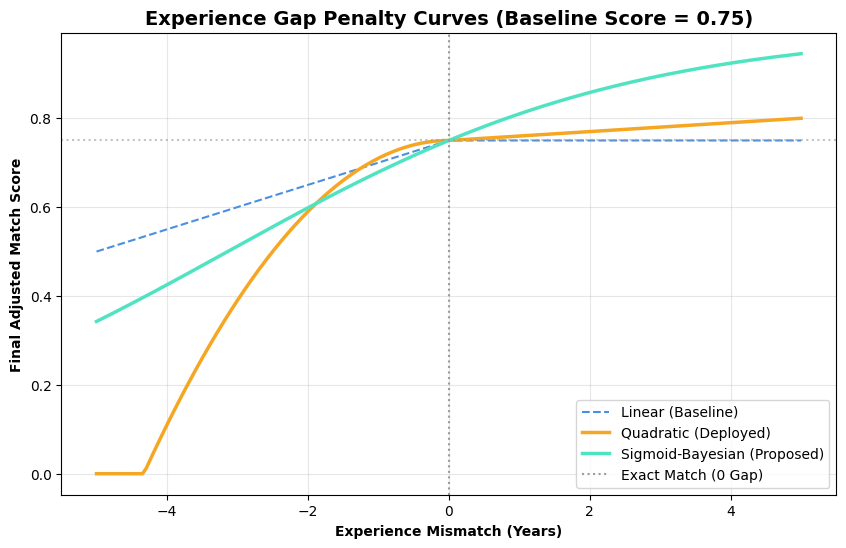


=================== CANDIDATE SCORING RESULTS ===================
   Delta_E  Match_Score  Human_Target_Score  Score_Linear  Score_Quadratic  \
0     -4.0         0.82                0.30         0.620             0.18   
1     -2.0         0.78                0.65         0.680             0.62   
2      0.0         0.75                0.75         0.750             0.75   
3      2.0         0.70                0.72         0.700             0.72   
4      3.0         0.88                0.90         0.880             0.91   
5      5.0         0.65                0.68         0.650             0.70   
6     -4.5         0.91                0.15         0.685             0.10   

   Score_Sigmoid  
0          0.529  
1          0.638  
2          0.750  
3          0.825  
4          0.954  
5          0.914  
6          0.677  

================ METHOD PERFORMANCE (SPEARMAN) ================
Higher score = Better alignment with human recruiter decisions.

      Method  Spearman_Sco

In [5]:
# 1. Display the visual comparison
plot_method_comparison()

# 2. Create sample candidate data
dummy_data = pd.DataFrame({
    "Exp_cand":    [1.0,  3.0,  5.0,  5.0,  8.0, 10.0, 0.5],
    "Exp_req":     [5.0,  5.0,  5.0,  3.0,  5.0,  5.0, 5.0],
    "Match_Score": [0.82, 0.78, 0.75, 0.70, 0.88, 0.65, 0.91],
    # The 'Ground Truth' - How a real HR professional ranked them (0.0 to 1.0)
    "Human_Target_Score": [0.30, 0.65, 0.75, 0.72, 0.90, 0.68, 0.15]
})

# 3. Process the data
processed_data = apply_methods(dummy_data)

columns_to_view = ["Delta_E", "Match_Score", "Human_Target_Score",
                   "Score_Linear", "Score_Quadratic", "Score_Sigmoid"]

print("\n=================== CANDIDATE SCORING RESULTS ===================")
print(processed_data[columns_to_view].round(3))

print("\n================ METHOD PERFORMANCE (SPEARMAN) ================")
print("Higher score = Better alignment with human recruiter decisions.\n")
print(evaluate_rankings(processed_data))